In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import pandas as pd

data = pd.read_csv("/kaggle/input/datasets/nomzznjs/final-submission-file/submission (3).csv")
data.to_csv("submission.csv", index = False)

<H1>Wandb(weights and biases) setup:</H1>

In [ ]:
!pip install wandb

In [ ]:
import os
import wandb
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    wandb_key = user_secrets.get_secret("WANDB_API_KEY")
    print(wandb_key)
    
    #login to WandB using the key
    wandb.login(key=wandb_key)
    print("Successful connected with Weights & Biases!")
    
except Exception as e:
    print("Error, not logged in")
    print(f"Details: {e}")


trying out ensembles:

In [ ]:
import numpy as np
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(train.shape)
print(test.shape)

In [ ]:
distilbert_test_probs = np.load(
    "/kaggle/input/datasets/nomzznjs/ensemble-prob/distilbert_test_probs.npy"
)

bilstm_test_probs = np.load("/kaggle/input/datasets/nomzznjs/ensemble-prob/bilstm_test_probs.npy")

In [ ]:
ensemble_test_probs = (33*distilbert_test_probs + 67*bilstm_test_probs)

In [ ]:
label2id = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4}

id2label = {v:k for k,v in label2id.items()}

train['label'] = train['answer'].map(label2id)

In [ ]:
ensemble_predictions = []

for probs in ensemble_test_probs:
    top3 = np.argsort(probs)[::-1][:3]

    labels = [id2label[i] for i in top3]

    ensemble_predictions.append(" ".join(labels))

In [ ]:
submission = pd.DataFrame({"id": test["id"], "Prediction": ensemble_predictions})

submission.to_csv("submission.csv", index=False)

In [ ]:
'''import pandas as pd

data = pd.read_csv("/kaggle/input/datasets/nomzznjs/ensemble-submission/submission_ensemble.csv")
data.to_csv("submission.csv", index = False)'''

<h3>SCRATCH MODEL - BiLSTM:</h3>

Importing basic stuff

In [1]:
import re
import random
import numpy as np
import pandas as pd

from collections import Counter

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from tqdm.auto import tqdm

import wandb

setting seed for reproducibility:

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

using gpu:

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


setting up train and test

In [4]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(train.shape)
print(test.shape)

(2000, 8)
(500, 7)


In [5]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


<h3>EDA</h3>
Before setting up anything, we'll do EDA, to know about the data.
we analyse the distribution of answers, prompt lengths, option lengths, duplicate prompts, and possible train-test overlap.

In [6]:
import matplotlib.pyplot as plt
#cause i dont wanna edit the main train/test files.
eda_train = train.copy()
eda_test = test.copy()

print("Training data shape:", eda_train.shape)
print("Test data shape:", eda_test.shape)

Training data shape: (2000, 8)
Test data shape: (500, 7)


Checking the frequency of each answer option:

In [7]:
answer_counts = eda_train['answer'].value_counts().reindex(['A', 'B', 'C', 'D', 'E'])
print(answer_counts)

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


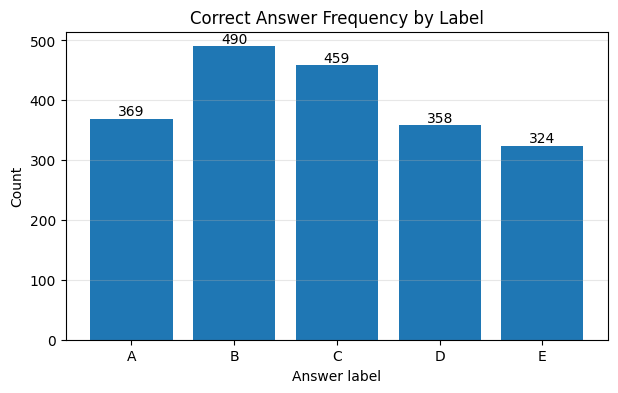

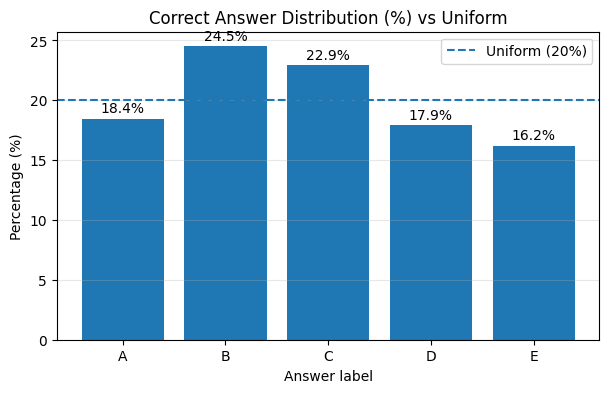

In [8]:
#for percentage
answer_percent = answer_counts / len(eda_train) * 100

#the frequency graph
plt.figure(figsize=(7, 4))

bars = plt.bar(answer_counts.index, answer_counts.values)

plt.title("Correct Answer Frequency by Label")
plt.xlabel("Answer label")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(int(height)), ha='center')

plt.show()


#the percentage graph
plt.figure(figsize=(7, 4))

bars = plt.bar(answer_percent.index, answer_percent.values)

plt.axhline(y=20, linestyle='--', label='Uniform (20%)')

plt.title("Correct Answer Distribution (%) vs Uniform")
plt.xlabel("Answer label")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

#percentag above bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%", ha='center')

plt.show()

Checking the length of options in both characters nad words:

In [9]:
eda_train['prompt_length_chars'] = eda_train['prompt'].astype(str).str.len()

eda_train['prompt_length_words'] = eda_train['prompt'].astype(str).str.split().str.len()

print("Character length:")
print("Mean:", eda_train['prompt_length_chars'].mean())
print("Median:", eda_train['prompt_length_chars'].median())
print("Maximum:", eda_train['prompt_length_chars'].max())

print("\nWord length:")
print("Mean:", eda_train['prompt_length_words'].mean())
print("Median:", eda_train['prompt_length_words'].median())
print("Maximum:", eda_train['prompt_length_words'].max())

Character length:
Mean: 117.6695
Median: 111.0
Maximum: 337

Word length:
Mean: 18.1465
Median: 17.0
Maximum: 51


graoh for the same:

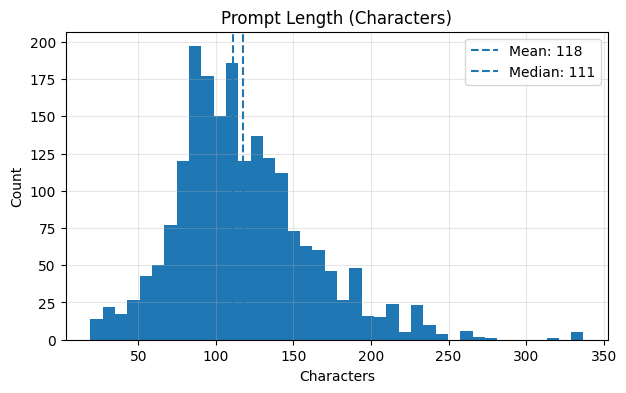

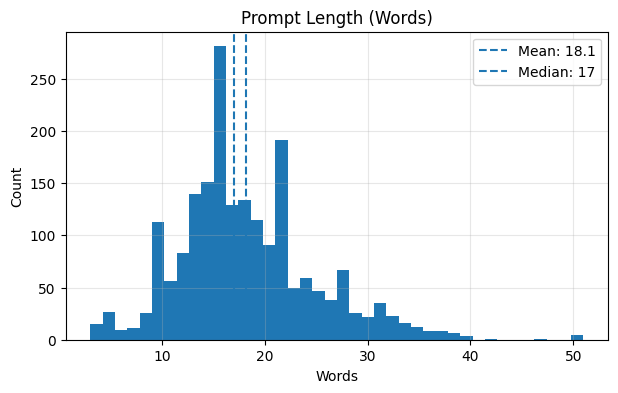

In [10]:
#plotting character length
plt.figure(figsize=(7, 4))

plt.hist(eda_train['prompt_length_chars'], bins=40)

mean_chars = eda_train['prompt_length_chars'].mean()
median_chars = eda_train['prompt_length_chars'].median()

plt.axvline(mean_chars, linestyle='--', label=f"Mean: {mean_chars:.0f}")

plt.axvline(median_chars, linestyle='--', label=f"Median: {median_chars:.0f}")

plt.title("Prompt Length (Characters)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


#plotting word length
plt.figure(figsize=(7, 4))

plt.hist(eda_train['prompt_length_words'], bins=40)

mean_words = eda_train['prompt_length_words'].mean()
median_words = eda_train['prompt_length_words'].median()

plt.axvline(mean_words, linestyle='--', label=f"Mean: {mean_words:.1f}")

plt.axvline(median_words, linestyle='--', label=f"Median: {median_words:.0f}")

plt.title("Prompt Length (Words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Checking the Option length:

/tmp/ipykernel_58/2409976872.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(option_lengths, labels=['A', 'B', 'C', 'D', 'E'])


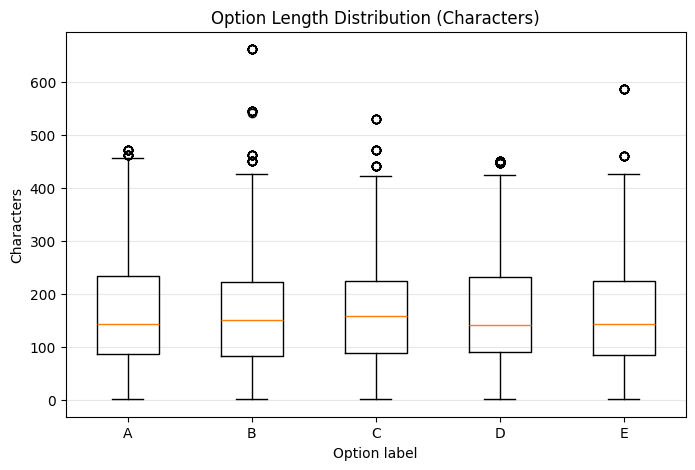

Average correct answer length: 181.879
Average wrong answer length: 160.712375


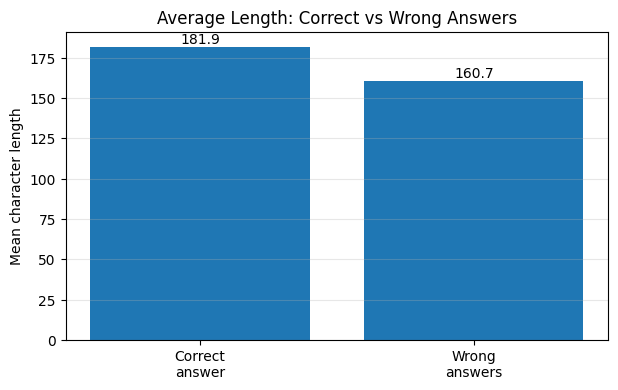

In [11]:
#length of every option
for option in ['A', 'B', 'C', 'D', 'E']:
    eda_train[option + '_length'] = eda_train[option].astype(str).str.len()


#boxplot

option_lengths = [
    eda_train['A_length'],
    eda_train['B_length'],
    eda_train['C_length'],
    eda_train['D_length'],
    eda_train['E_length']
]

plt.figure(figsize=(8, 5))

plt.boxplot(option_lengths, labels=['A', 'B', 'C', 'D', 'E'])

plt.title("Option Length Distribution (Characters)")
plt.xlabel("Option label")
plt.ylabel("Characters")
plt.grid(axis='y', alpha=0.3)
plt.show()


#the graph of correct vs wrong

correct_lengths = []
wrong_lengths = []

for _, row in eda_train.iterrows():
    correct_option = row['answer']
    for option in ['A', 'B', 'C', 'D', 'E']:
        length = row[option + '_length']
        if option == correct_option:
            correct_lengths.append(length)
        else:
            wrong_lengths.append(length)


correct_average = sum(correct_lengths) / len(correct_lengths)
wrong_average = sum(wrong_lengths) / len(wrong_lengths)

print("Average correct answer length:", correct_average)
print("Average wrong answer length:", wrong_average)


plt.figure(figsize=(7, 4))

labels = ['Correct\nanswer', 'Wrong\nanswers']
values = [correct_average, wrong_average]

bars = plt.bar(labels, values)

plt.title("Average Length: Correct vs Wrong Answers")
plt.ylabel("Mean character length")
plt.grid(axis='y', alpha=0.3)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f"{height:.1f}", ha='center')

plt.show()

Checking for train test duplication:

In [12]:
train_unique_prompts = eda_train['prompt'].nunique()
test_unique_prompts = eda_test['prompt'].nunique()

print("Unique prompts in training set:", train_unique_prompts)
print("Unique prompts in test set:", test_unique_prompts)


#for the unique test prompts that are in training too
train_prompt_set = set(eda_train['prompt'])
test_prompt_set = set(eda_test['prompt'])

overlapping_unique_prompts = test_prompt_set.intersection(train_prompt_set)

print("Unique test prompts also present in training:", len(overlapping_unique_prompts))


#training rows whose prompt appears in test
train_rows_overlapping = eda_train['prompt'].isin(test_prompt_set).sum()

print("Training rows whose prompt also appears in test:", train_rows_overlapping)


# Number of test rows whose prompt appears in training
test_rows_overlapping = eda_test['prompt'].isin(train_prompt_set).sum()

print("Test rows whose prompt also appears in training:", test_rows_overlapping)


# Percentage of test rows affected
overlap_percentage = test_rows_overlapping / len(eda_test) * 100

print(f"Percentage of test rows with a training prompt match: " f"{overlap_percentage:.1f}%")

Unique prompts in training set: 1758
Unique prompts in test set: 492
Unique test prompts also present in training: 267
Training rows whose prompt also appears in test: 281
Test rows whose prompt also appears in training: 268
Percentage of test rows with a training prompt match: 53.6%


encoding labels:

In [ ]:
label2id = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4}

id2label = {v:k for k,v in label2id.items()}

train['label'] = train['answer'].map(label2id)

text cleaning(putting in lowercase and removing the exclamation marks etc):

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  #saw this from google
    text = re.sub(r"\s+", " ", text)
    return text.strip()

Applying that cleaning:

In [ ]:
columns = ["prompt", "A", "B", "C", "D","E"]

for col in columns:
    train[col] = train[col].apply(clean_text)
    test[col] = test[col].apply(clean_text)

Building the vocab

In [ ]:
counter = Counter()

for _, row in train.iterrows():
    text = " ".join([row["prompt"], row["A"], row["B"], row["C"], row["D"], row["E"]])

    counter.update(text.split())

Creating the word dictionary:

In [ ]:
MIN_FREQ = 2

vocab = {"<PAD>":0, "<UNK>":1}

for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

print("Vocabulary Size :", len(vocab))

Creating the tokenizer:

In [ ]:
def tokenize(text):
    tokens = text.split()

    ids = [vocab.get(token,vocab["<UNK>"])for token in tokens]
    return ids

In [ ]:
sample = train.iloc[0]["prompt"]
print(sample)
print()

print(tokenize(sample)[:20])

training validation split:

In [ ]:
train_df, valid_df = train_test_split(train, test_size=0.15, random_state=42, stratify=train["label"])

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

All the question + option pair will be padded:

In [ ]:
MAX_LEN = 120
#padding function
def pad_sequence(sequence, max_len):

    if len(sequence) >= max_len:

        return sequence[:max_len]

    return sequence + [vocab["<PAD>"]] * (max_len - len(sequence))

Putting the question with each option:

In [ ]:
def encode_pair(question, option):
    text = question + " " + option

    ids = tokenize(text)
    ids = pad_sequence(ids, MAX_LEN)
    return ids

Custom pytorch Dataset:

In [ ]:
class MCQDataset(Dataset):

    def __init__(self, dataframe, train=True):
        self.df = dataframe
        self.train = train

    def __len__(self):
        return len(self.df)

    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        question = row["prompt"]

        options = [row["A"], row["B"], row["C"], row["D"], row["E"]]
        encoded = []

        for option in options:
            ids = encode_pair(question, option)
            encoded.append(ids)

        encoded = torch.tensor(encoded,dtype=torch.long)

        item = {"input_ids": encoded}

        if self.train:
            item["label"] = torch.tensor(row["label"], dtype=torch.long)
        return item

Dataset creating:

In [ ]:
train_dataset = MCQDataset(train_df, train=True)
valid_dataset = MCQDataset(valid_df,train=True)

test_dataset = MCQDataset(test, train=False)

testing our dataset:

In [ ]:
sample = train_dataset[0]

print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["label"])

Dataloader

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

test_loader = DataLoader( test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2)

just to check:

In [ ]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)

print(batch["label"].shape)

Vocab detail stats:

In [ ]:
print(f"Vocabulary Size : {len(vocab)}")

print(f"Training Samples : {len(train_dataset)}")

print(f"Validation Samples : {len(valid_dataset)}")

print(f"Test Samples : {len(test_dataset)}")

Hyper-parameters:

In [ ]:
EMBED_DIM = 300
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.3

Attention Layer:

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size * 2, hidden_size)

        self.context = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_output):
        scores = torch.tanh(
            self.attention(lstm_output))
        
        scores = self.context(scores)

        weights = torch.softmax(scores, dim=1)

        weighted = lstm_output * weights

        context = weighted.sum(dim=1)

        return context

BiLSTM MCQ Solver:

In [ ]:
class BiLSTMMCQ(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)

        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_SIZE, num_layers=NUM_LAYERS, 
                            batch_first=True, dropout=DROPOUT, bidirectional=True)

        self.attention = Attention(HIDDEN_SIZE)

        self.dropout = nn.Dropout(DROPOUT)

        self.fc = nn.Linear(HIDDEN_SIZE * 4,1)

    def forward(self, input_ids):
        batch_size = input_ids.size(0)
        num_choices = input_ids.size(1)

        seq_len = input_ids.size(2)

        input_ids = input_ids.view(batch_size * num_choices, seq_len)

        embeddings = self.embedding(input_ids)

        outputs, _ = self.lstm(embeddings)
        
        #attention pooling plus max pooling:
        attention_output = self.attention(outputs)

        max_pool, _ = torch.max(outputs, dim=1)
        
        context = torch.cat([attention_output, max_pool], dim=1)

        context = self.dropout(context)

        logits = self.fc(context)

        logits = logits.view(batch_size, num_choices)
        return logits

Initialising model:

In [ ]:
model = BiLSTMMCQ(len(vocab))

model = model.to(device)

print(model)

Calculating total Parameters:

In [ ]:
total_params = sum(p.numel()for p in model.parameters())

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Loss function and optimizer:

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

learning rate scheduler

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", 
                                                       factor=0.5, patience=1)

just to check everything:

In [ ]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
output = model(input_ids)

print(output.shape)

Initialize WandB:

In [ ]:
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    wandb_key = user_secrets.get_secret("WANDB_API_KEY")
    
    #login to WandB using the key
    wandb.login(key=wandb_key)
    print("Successful connected with Weights & Biases!")
    
except Exception as e:
    print("Error, not logged in")
    print(f"Details: {e}")

wandb.login()

wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="23f2004641-dl-genai-project-",
    # Set the wandb project where this run will be logged.
    project="DL-GenAI-2026-T2",

    name="biLSTM + attention",
    # Track hyperparameters and run metadata.
    config={
        "epochs": 15,
        "batch_size": BATCH_SIZE,
        "learning_rate": 2e-4,
        "embedding_dim":EMBED_DIM,
        "hidden_size":HIDDEN_SIZE,
        "model": "biLSTM+attention",
        "dropout": DROPOUT
    },
)



"""wandb.init(

    project="MCQ-Solver",

    name="DistilBERT-Baseline",

    config={

        "epochs": EPOCHS,

        "batch_size": BATCH_SIZE,

        "learning_rate": 2e-5,

        "model": MODEL_NAME

    }

)"""

Map@3 function:

In [ ]:
def map3_score(predictions, labels):
    score = 0

    for pred, label in zip(predictions, labels):
        top3 = np.argsort(pred)[::-1][:3]
        if label == top3[0]:
            score += 1
        elif label == top3[1]:
            score += 0.5
        elif label == top3[2]:
            score += 1/3
            
    return score / len(labels)

Training func:

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    predictions = []

    labels = []
    progress = tqdm(loader)

    for batch in progress:
        input_ids = batch["input_ids"].to(device)
        target = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids)

        loss = criterion(logits, target)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())

        labels.extend(target.cpu().numpy())

        progress.set_postfix(loss=loss.item())

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions, average="macro")

    return (total_loss / len(loader), accuracy, f1)

Validation Function:

In [ ]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    predictions = []

    probabilities = []

    labels = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)

            target = batch["label"].to(device)

            logits = model(input_ids)

            loss = criterion(logits, target)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            pred = torch.argmax(probs, dim=1)

            predictions.extend(pred.cpu().numpy())
            probabilities.extend(probs.cpu().numpy())

            labels.extend(target.cpu().numpy())

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")

    map3 = map3_score(probabilities, labels)

    return (total_loss / len(loader), accuracy, f1, map3)

Optimizer:

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Training Loop(with early stopping):

In [ ]:
EPOCHS = 15
best_map3 = 0
patience = 3
counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader)

    val_loss, val_acc, val_f1, val_map3 = validate(model, valid_loader)

    scheduler.step(val_map3)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Train F1 : {train_f1:.4f}")
    print()

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Validation F1 : {val_f1:.4f}")
    print(f"Validation MAP@3 : {val_map3:.4f}")

    wandb.log({"Train Loss":train_loss, "Train Accuracy":train_acc, "Train F1":train_f1,
        "Validation Loss":val_loss, "Validation Accuracy":val_acc,"Validation F1":val_f1,
        "Validation MAP@3":val_map3})

    if val_map3 > best_map3:
        best_map3 = val_map3
        counter = 0
        torch.save(model.state_dict(), "/kaggle/working/bilstm_best_model.pth")

        print("Best Model Saved")

    else:
        counter += 1

    if counter >= patience:
        print("Early Stopping")
        break

loading the best model:

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/bilstm_best_model.pth"))
model.eval()

following four cells are for ensembling:

In [ ]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/bilstm_best_model.pth"
    )
)

model.eval()

In [ ]:
bilstm_val_probs = []
bilstm_val_labels = []

with torch.no_grad():

    for batch in tqdm(valid_loader):

        input_ids = batch["input_ids"].to(device)

        labels = batch["label"]

        logits = model(input_ids)

        probs = torch.softmax(
            logits,
            dim=1
        )

        bilstm_val_probs.append(
            probs.cpu().numpy()
        )

        bilstm_val_labels.append(
            labels.numpy()
        )

bilstm_val_probs = np.concatenate(
    bilstm_val_probs,
    axis=0
)

bilstm_val_labels = np.concatenate(
    bilstm_val_labels,
    axis=0
)

print(bilstm_val_probs.shape)

print(bilstm_val_labels.shape)

In [ ]:
bilstm_test_probs = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)

        logits = model(input_ids)

        probs = torch.softmax(
            logits,
            dim=1
        )

        bilstm_test_probs.append(
            probs.cpu().numpy()
        )

bilstm_test_probs = np.concatenate(
    bilstm_test_probs,
    axis=0
)

print(bilstm_test_probs.shape)

In [ ]:
np.save(
    "/kaggle/working/bilstm_test_probs.npy",
    bilstm_test_probs
)

np.save(
    "/kaggle/working/bilstm_val_probs.npy",
    bilstm_val_probs
)

MAP@3 for ensembling:

In [ ]:
def calculate_map3(probabilities, labels):

    score = 0.0

    for probs, label in zip(
        probabilities,
        labels
    ):

        ranking = np.argsort(
            probs
        )[::-1][:3]

        if ranking[0] == label:

            score += 1.0

        elif ranking[1] == label:

            score += 0.5

        elif ranking[2] == label:

            score += 1/3

    return score / len(labels)

loading distilbert probabilities:

In [ ]:
distilbert_test_probs = np.load(
    "/kaggle/input/datasets/nomzznjs/ensembling-probabilities/distilbert_test_probs.npy"
)

distilbert_val_probs = np.load(
    "/kaggle/input/datasets/nomzznjs/ensembling-probabilities/distilbert_val_probs.npy"
)

distilbert_val_labels = np.load(
    "/kaggle/input/datasets/nomzznjs/ensembling-probabilities/distilbert val_labels.npy"
)

checking dimensions:

In [ ]:
print(
    "DistilBERT validation:",
    distilbert_val_probs.shape
)

print(
    "BiLSTM validation:",
    bilstm_val_probs.shape
)

print(
    "Labels:",
    distilbert_val_labels.shape
)

Testing prediction:

In [ ]:
predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)

        logits = model(input_ids)
        probs = torch.softmax(logits, dim=1)

        probs = probs.cpu().numpy()

        for p in probs:
            top3 = np.argsort(p)[::-1][:3]
            labels = [id2label[i] for i in top3]

            predictions.append(" ".join(labels))

all_probs = []
predictions = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)

        logits = model(input_ids)

        probs = torch.softmax(logits, dim=1)

        probs_np = probs.cpu().numpy()

        all_probs.extend(probs_np)

        for p in probs_np:

            top3 = np.argsort(p)[::-1][:3]

            predictions.append(
                " ".join([id2label[x] for x in top3])
            )

saving probabilities for ensembling later:

In [ ]:
np.save(
    "/kaggle/working/bilstm_probs.npy",
    np.array(all_probs)
)

finding tghe best weights:

In [ ]:
weights = np.arange(
    0.0,
    1.01,
    0.05
)

results = []

for w in weights:

    ensemble_probs = (

        w * distilbert_val_probs

        +

        (1 - w) * bilstm_val_probs

    )

    score = calculate_map3(
        ensemble_probs,
        distilbert_val_labels
    )

    results.append({

        "distilbert_weight": w,

        "bilstm_weight": 1-w,

        "MAP@3": score

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "MAP@3",
    ascending=False
)

results_df.head(10)

In [ ]:
best_row = results_df.iloc[0]

best_distilbert_weight = (
    best_row["distilbert_weight"]
)

best_bilstm_weight = (
    best_row["bilstm_weight"]
)

print(
    "Best DistilBERT weight:",
    best_distilbert_weight
)

print(
    "Best BiLSTM weight:",
    best_bilstm_weight
)

print(
    "Best Validation MAP@3:",
    best_row["MAP@3"]
)

finding the best weights:

In [ ]:
best_w = best_distilbert_weight

fine_weights = np.arange(
    max(0, best_w - 0.10),
    min(1, best_w + 0.10) + 0.001,
    0.01
)

fine_results = []

for w in fine_weights:

    ensemble_probs = (

        w * distilbert_val_probs

        +

        (1-w) * bilstm_val_probs

    )

    score = calculate_map3(
        ensemble_probs,
        distilbert_val_labels
    )

    fine_results.append({

        "distilbert_weight": w,

        "bilstm_weight": 1-w,

        "MAP@3": score

    })

fine_results_df = pd.DataFrame(
    fine_results
).sort_values(
    "MAP@3",
    ascending=False
)

fine_results_df.head(10)

final ensembling:

In [ ]:
ensemble_test_probs = (

    70
    * distilbert_test_probs

    +

    30
    * bilstm_test_probs

)

converting these probabilities into labels:

In [ ]:
ensemble_predictions = []

for probs in ensemble_test_probs:

    top3 = np.argsort(
        probs
    )[::-1][:3]

    labels = [

        id2label[i]

        for i in top3

    ]

    ensemble_predictions.append(
        " ".join(labels)
    )

creating the final submission:

In [ ]:
submission = pd.DataFrame({

    "id": test["id"],

    "Prediction": ensemble_predictions

})

submission.to_csv(
    "/kaggle/working/submission_ensemble.csv",
    index=False
)

Creating a submission file:

In [ ]:
submission = pd.DataFrame({"id":test["id"], "Prediction":predictions})

submission.to_csv("/kaggle/working/submission_bilstm.csv", index=False)

submission.head()

WandB run close:

In [ ]:
wandb.finish()

<hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr><hr>

<h1>For dummy submission initially</h1>

In [ ]:
'''import pandas as pd

data = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
data.to_csv("submission.csv", index = False)'''

<h1>Importing all dependencies required:</h1>

In [ ]:
import pandas as pd
import numpy as np
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

<h1>The following is for Milestone 1</h1>
<hr>
<h3>Question 1:</h3> Calculate the frequency distribution of the correct  answer  (A, B, C, D, E) in train.csv. Based on your counts, what is the sum of the occurrences of the most frequent option and the least frequent option?  

In [ ]:
counts = df['answer'].value_counts()
sum_most_and_least = counts.max() + counts.min()
sum_most_and_least

<h3>Question 2:</h3> After converting the prompt column to lowercase and removing all standard punctuation characters (using Python's string.punctuation), split the text by whitespace. What is the total number of unique words (vocabulary size) across the entire cleaned prompt column of train.csv?  

In [ ]:
def clean_text(text):
    text = text.lower()
    return text.translate(str.maketrans('', '', string.punctuation))

cleaned_prompts = df['prompt'].apply(clean_text)
vocab = set(' '.join(cleaned_prompts).split())
len(vocab)

<h3>Question 3:</h3> Using the cleaned prompt from Row ID 1, filter out the standard English stop words using sklearn.feature_extraction.text.ENGLISH_STOP_WORDS. How many words are left in the prompt for Row ID 1 after filtering?  

In [ ]:
row1_tokens = clean_text(df.iloc[0]['prompt']).split()
filtered_tokens = [w for w in row1_tokens if w not in ENGLISH_STOP_WORDS]
len(filtered_tokens)

<h3>Question 4:</h3> Fit a default TfidfVectorizer(stop_words='english') on a list containing all the combined text of the prompts and options in train.csv. What is the exact total number of feature columns (vocabulary size) generated by the vectorizer?  

In [ ]:
combined_text = df['prompt'] + " " + df['A'] + " " + df['B'] + " " + df['C'] + " " + df['D'] + " " + df['E']
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(combined_text)
len(vectorizer.get_feature_names_out())

<h3>Question 5:</h3> Using the TF-IDF vectorizer fitted in Question 3, calculate the cosine similarity between the prompt and option A strictly for Row ID 1. What is the resulting similarity score? (Round to 4 decimal places).  

In [ ]:
prompt_vec = vectorizer.transform([df.iloc[0]['prompt']])
option_a_vec = vectorizer.transform([df.iloc[0]['A']])
round(cosine_similarity(prompt_vec, option_a_vec)[0][0], 4)

<h3>Question 6:</h3> Expand the logic from Question 4: For every row in train.csv, calculate the cosine similarity between the prompt and each of its 5 options .  Then calculate the percentage of instances where the option with the highest cosine similarity matches the correct answer.   

In [ ]:
def get_best_option(row):
    options = ['A', 'B', 'C', 'D', 'E']
    prompt_v = vectorizer.transform([row['prompt']])
    scores = {opt: cosine_similarity(prompt_v, vectorizer.transform([row[opt]]))[0][0] for opt in options}
    return max(scores, key=scores.get)

matches = df.apply(lambda row: get_best_option(row) == row['answer'], axis=1)
matches.mean() * 100

<h3>Question 7:</h3> If the ground truth answer for a question is C, what is the MAP@3 score if a model predicts C A B?  

In [ ]:
gt_7 = 'C'
pred_7 = ['C', 'A', 'B']

score_7 = 1 / (pred_7.index(gt_7) + 1) if gt_7 in pred_7[:3] else 0.0

score_7

<h3>Question 8:</h3> The Majority Class Baseline: Find the most frequent correct answer in the training set (using your data from Q1). Make a static prediction for every single row where that most frequent answer is your 1st guess, followed by the second most frequent, and then the third most frequent. What is the overall MAP@3 score of this "Majority Class" baseline on train.csv?

In [ ]:
gt_8 = 'B'
pred_8 = ['D', 'B', 'E']

score_8 = 1 / (pred_8.index(gt_8) + 1) if gt_8 in pred_8[:3] else 0.0
score_8

<h3>Question 9:</h3> The Majority Class Baseline: Find the most frequent correct answer in the training set (using your data from Q1). Make a static prediction for every single row where that most frequent answer is your 1st guess, followed by the second most frequent, and then the third most frequent. What is the overall MAP@3 score of this "Majority Class" baseline on train.csv?

In [ ]:
top_3_answers = df['answer'].value_counts().index[:3].tolist()
baseline_map3 = df['answer'].apply(
    lambda ans: 1.0 if ans == top_3_answers[0] else 
               (0.5 if ans == top_3_answers[1] else 
               (1/3 if ans == top_3_answers[2] else 0.0))
).mean()
baseline_map3

<h3>Question 10:</h3> The TF-IDF Pipeline: Build a basic pipeline that evaluates every row in train.csv. For each row, calculate the TF-IDF cosine similarity between the prompt and each of the 5 options. Sort these options from highest similarity to lowest to form your top 3 predictions. What is the final average MAP@3 score of this TF-IDF pipeline across the entire training set?  

In [ ]:
def map_at_3(truth, predictions):
    if truth in predictions[:3]:
        rank = predictions.index(truth) + 1
        return 1 / rank
    return 0


def get_top3_preds(row):
    options = ['A', 'B', 'C', 'D', 'E']
    p_v = vectorizer.transform([row['prompt']])
    s = {opt: cosine_similarity(p_v, vectorizer.transform([row[opt]]))[0][0] for opt in options}
    return sorted(s, key=s.get, reverse=True)

all_scores = df.apply(lambda row: map_at_3(row['answer'], get_top3_preds(row)), axis=1)
all_scores.mean()

<h1> MILESTONE 2:</h1>
<HR>


In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

file_path = '/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv'
dataset = load_dataset('csv', data_files=file_path)['train']

<h3>Question 1 - intro to hugging face transformers and models</h3> 
Load train.csv using the Hugging Face datasets library (do not use pandas). Use the .map() function to create a new column called combined_text that concatenates the prompt and A columns with a space in between. E.g., prompt_text A_text. What is the exact character length (total number of string characters using Python's len() function, NOT the number of tokens) of the combined_text string for the row at index 51? Note: We follow zero-indexing here.

In [ ]:
def combine_text(example):
    example['combined_text'] = str(example['prompt']) + " " + str(example['A'])
    return example

dataset = dataset.map(combine_text)
combined_text_51 = dataset[51]['combined_text']
len(combined_text_51)

<h3>Question 2 - </h3>
Initialize the bert-base-uncased tokenizer. Look at the tokenizer's configuration properties: what is the exact total vocabulary size (the maximum number of unique subword tokens the model knows) hardcoded into this tokenizer?  

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer.vocab_size

<h3> Question 3 - </h3>
Transformers rely on special tokens to understand sentence boundaries. Using the bert-base-uncased tokenizer from the previous step, extract the exact integer ID assigned to the [SEP] (Separator) token.  

In [ ]:
#exact ID for the SEP token:
tokenizer.sep_token_id

<h3> Question 4 - </h3>
Using the bert-base-uncased tokenizer, tokenize the entire prompt column of the train dataset simultaneously. Set padding='max_length', truncation=True, max_length=128, and return_tensors='pt' (PyTorch tensors). 

What is the exact geometric shape (dimensions) of the resulting input_ids tensor?

In [ ]:
prompts_list = [str(text) for text in dataset['prompt']]

tokens = tokenizer(prompts_list, padding='max_length', truncation=True, max_length=128, 
    return_tensors='pt')
tokens['input_ids'].shape


<h3>Question 5 - BERT/RoBERTa architecture and attention mechanisms</h3>
A standard bert-base-uncased model has a hidden embedding size of 768 dimensions and uses exactly 12 attention heads in each layer. 

In Transformer architecture, the hidden size is divided equally among the attention heads. What is the exact dimensionality (size) of each individual attention head?  


In [ ]:
import torch
from transformers import AutoModel

hidden_size = 768
attention_heads = 12
head_dim = hidden_size / attention_heads
print(int(head_dim))

<h3>Question 6 - </h3>
Load the bert-base-uncased model using AutoModel.from_pretrained(). Tokenize the prompt from row ID 0 using the tokenizer's default settings (do not apply any manual padding or truncation). Pass this tokenized input through the model. Look at the output object. 

What is the exact shape of the last_hidden_state tensor returned? 

Note: We follow zero-indexing here.

In [ ]:
model = AutoModel.from_pretrained('bert-base-uncased')
inputs_row_0 = tokenizer(dataset[0]['prompt'], return_tensors='pt')

with torch.no_grad():
    outputs_row_0 = model(**inputs_row_0)
outputs_row_0.last_hidden_state.shape

<h3>Question 7 - </h3>
Using the last_hidden_state tensor from the previous question, extract the embedding vector representing the [CLS] token (which is always the token at index 0). What is the sum of the first 5 float values in this [CLS] vector? (Round your answer to 4 decimal places).  

In [ ]:
cls_vector = outputs_row_0.last_hidden_state[0, 0, :] # Batch 0, Token 0
sum_first_5 = cls_vector[:5].sum().item()
round(sum_first_5, 4)

<h3>Question 8 - </h3>
Load bert-base-uncased with the parameter output_attentions=True. Tokenize the exact string "Light-ion fusion is a technique." (ensuring you set return_tensors='pt') and pass it through the model. Extract the attention matrix for the last layer (index -1) and the first attention head (head index 0). 

What is the exact attention weight (a float value) that the [CLS] token (token index 0) pays to the word fusion (you will need to find the specific token index for fusion in the input_ids)? (Round your answer to 4 decimal places).  

In [ ]:
model_attn = AutoModel.from_pretrained('bert-base-uncased', output_attentions=True)
test_string = "Light-ion fusion is a technique."
inputs_attn = tokenizer(test_string, return_tensors='pt')

with torch.no_grad():
    outputs_attn = model_attn(**inputs_attn)

tokens_list = tokenizer.convert_ids_to_tokens(inputs_attn['input_ids'][0])
fusion_index = tokens_list.index('fusion')

attention_matrix = outputs_attn.attentions[-1]
attention_weight = attention_matrix[0, 0, 0, fusion_index].item()
print(f"Q8 - Attention weight paid to 'fusion': {round(attention_weight, 4)}")

<h3>Question 9 - context aware embeddings questions</h3>
Initialize the sentence-transformers/all-MiniLM-L6-v2 model. Use the model's .encode() method to generate embeddings for both the prompt and Option B for row ID 0. Calculate the cosine similarity between these two vectors specifically using the sentence_transformers.util.cos_sim() function. What is the resulting similarity score rounded to 4 decimal places? Note: We follow zero-indexing here.


In [ ]:
from sentence_transformers import SentenceTransformer, util

model_st = SentenceTransformer('all-MiniLM-L6-v2')

prompt_emb = model_st.encode(dataset[0]['prompt'])
option_b_emb = model_st.encode(dataset[0]['B'])

similarity = util.cos_sim(prompt_emb, option_b_emb).item()
round(similarity, 4)

<h3>Question 10 - </h3>
Build two complete ranking pipelines evaluating every row in train.csv.

Pipeline 1: Use the TF-IDF cosine similarity approach from Milestone 1.

Pipeline 2: Use the sentence-transformers/all-MiniLM-L6-v2 model to generate embeddings for the prompt and all five options. Rank options using cosine similarity to form Top-3 predictions.

First, what is the final MAP@3 score of the all-MiniLM-L6-v2 pipeline across the entire training set? 

Second, count the number of questions for which the correct answer is NOT present in the TF-IDF Top-3 predictions BUT IS present in the MiniLM Top-3 predictions. What is this exact resulting count?  

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, util

sent_transformer_model = SentenceTransformer("all-MiniLM-L6-v2")

minilm_map3_score = []
specific_difference_count = 0
option_cols =['A', 'B', 'C', 'D', 'E']

for item in dataset:
    prompt = str(item['prompt'])
    options = [str(item[opt]) for opt in option_cols]
    correct_ans = item['answer']

    #the tf-idf pipeline
    vectorizer = TfidfVectorizer()
    docs = [prompt] + options
    tfidf_matrix = vectorizer.fit_transform(docs)

    tfidf_sims = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
    tfidf_top3_index = tfidf_sims.argsort()[-3:][::-1]
    tfidf_top3_pred = [option_cols[i] for i in tfidf_top3_index]

    #second pipeline for allMiniLM-L6-v2
    prompt_embed = model_st.encode(prompt, convert_to_tensor = True)
    options_embed = model_st.encode(options, convert_to_tensor = True)
    minilm_sims = util.cos_sim(prompt_embed, options_embed)[0].cpu().numpy()

    minilm_top3_index = minilm_sims.argsort()[-3:][::-1]
    minilm_top3_pred = [option_cols[i] for i in minilm_top3_index]

    #comparing
    if correct_ans in minilm_top3_pred:
        rank = minilm_top3_pred.index(correct_ans) + 1
        minilm_map3_score.append(1.0/rank)
    else:
        minilm_map3_score.append(0.0)

    if (correct_ans not in tfidf_top3_pred) and (correct_ans in minilm_top3_pred):
        specific_difference_count += 1


#final calculation
final_map3_score = np.mean(minilm_map3_score)
print(f"Final map@3 score of the all-MiniLM-L6-v2 pipline is: {final_map3_score:.4f}")
print(f"Count of questions meeting the conditions: {specific_difference_count}")

In [ ]:
574

<h3>Questions 11 - zero shot classification starts here</h3>
Initialize the Hugging Face pipeline for "zero-shot-classification" (it will default to facebook/bart-large-mnli). For the prompt of the 2nd row (index 1), pass Options A, B, and C as the candidate_labels. What is the probability score given to the top-ranked option? (Round to 4 decimal places).

In [ ]:
from transformers import pipeline

#setting up zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

prompt_idx_1 = dataset[1]['prompt']
labels_idx_1 = [str(dataset[1]['A']), str(dataset[1]['B']), str(dataset[1]['C'])]

# ques11, zero-shot classification , softmax- probability sum to 1
result_softmax = classifier(prompt_idx_1, candidate_labels=labels_idx_1)
top_score = result_softmax['scores'][0]
round(top_score, 4)

<h3>Question 12 - </h3>
Run the exact same zero-shot classification as the previous question, but this time pass the argument multi_label=True. 

What is the absolute difference between the sum of the 3 probabilities in the previous question (which uses Softmax) and the sum of the 3 probabilities in this question (which uses independent Sigmoids)?

In [ ]:
result_sigmoid = classifier(prompt_idx_1, candidate_labels=labels_idx_1, multi_label=True)

sum_softmax = sum(result_softmax['scores'])
sum_sigmoid = sum(result_sigmoid['scores'])
absolute_difference = abs(sum_softmax - sum_sigmoid)

round(absolute_difference, 4)

<h3>Question 13 - </h3>
Let's try Generative AI instead of Classification. 

Load a Small Language Model like google/flan-t5-small using the Hugging Face pipeline("text2text-generation"). Construct the following exact string for row index 0: "Question: [prompt]. Is the correct answer A: [A] or B: [B]? Answer with just the letter A or B." 
Pass this string to the pipeline, setting max_new_tokens=5. What is the exact string output returned by the model? 

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer_t5 = AutoTokenizer.from_pretrained("google/flan-t5-small")
model_t5 = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

prompt_str = f"Question: {dataset[0]['prompt']}. Is the correct answer A: {dataset[0]['A']} or B: {dataset[0]['B']}? Answer with just the letter A or B."

input_ids = tokenizer_t5(prompt_str, return_tensors="pt").input_ids
generated_tokens = model_t5.generate(input_ids, max_new_tokens=5)

exact_output = tokenizer_t5.decode(generated_tokens[0], skip_special_tokens=True)

exact_output

<h1>Milestone 3:</h1>
<hr>

<h4>Inital code to run(given in the milestone-3 google form)</h4>

In [ ]:
!pip install faiss-cpu #install FAISS

import pandas as pd 
import numpy as np 
import faiss 
from sentence_transformers import SentenceTransformer, CrossEncoder 
from transformers import AutoTokenizer, pipeline 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics.pairwise import cosine_similarity 

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv') 

print("Creating nowledge base")
kb = [] 
for idx, row in train.iterrows(): 
    correct_letter = row['answer'] 
    kb.append(str(row[correct_letter])) 

print("Loading embedding model and creating index") 
model = SentenceTransformer('all-MiniLM-L6-v2') 
kb_embeddings = model.encode(kb, show_progress_bar=False) 
index = faiss.IndexFlatL2(kb_embeddings.shape[1]) 
index.add(kb_embeddings)

print("Knowledge base successfully created")
#Zero-shot classifier for Q1, Q2, Q6
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") 
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

<h3>Question-1</h3>
Run the zero-shot classifier on facebook/bart-large-mnli on prompt for the row index 150. Pass the 5 options (A-E) candidate_labels. What is the predicted probability score assigned to the ground-truth correct option (option in the answer column)? (Round to 3 decimal points)

In [ ]:
result_150 = zs(prompt_150, candidate_labels=labels_150)
correct_idx = result_150['labels'].index(ans_150)

prob_score_q1 = round(result_150['scores'][correct_idx], 3)
prob_score_q1

<h3>Question-2</h3>
Embed the prompt for row index 150 using all-MiniLM-L6-v2. Query your FAISS index to retrieve the top k=10 most similar documents. At what exact rank (1 through 10) did FAISS place the true correct document (which is the document originally located at index 150 in the KB)?

In [ ]:
prompt_emb_150 = model.encode([prompt_150])
distances, indices = index.search(prompt_emb_150, k=10)

retrieved_indices = indices[0].tolist()
true_rank_faiss = retrieved_indices.index(150) + 1
true_rank_faiss

<h3>(The two stage pipeline: Reranking and cross-encoders)</h3>
In Question 2, you saw that our FAISS database did not put the true document at rank #1. Why? Because FAISS uses Bi-encoder. 
A Bi-encoder embeds the question and the document separately and just compares the distance (Cosine Similarity). They are fast and allows you to search millions of documents but often miss semantic context. 

To fix this we use a 2 stage pipeline:
1. Retrieval: Use a bi-encoder with FAISS to quickly get the top k possible chunks/documents.
2. Reranking: Use a Cross-Encoder to deeply evaluate those top candidates and sort them based on highest semantic similarity.

A Cross-Encoder passes the Question and the Document into the Transformer network at the exact same time. The Attention mechanism can directly compare the words in the question to the words in the document, resulting in a highly accurate relevance score.

For this we part the prompt and the context and ask it to predict a score.

Cross Encoders (Hugging Face)
Code to use a Cross-Encoder
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
docs_10 = [kb[i] for i in retrieved_indices] #Get the top 10 chunks
pairs = [[prompt_150, doc] for doc in docs_10] #Create prompt-context pairs
ce_scores = cross_encoder.predict(pairs) # Get the score of each pair

<h3>Question-3</h3>
Take the top 10 documents retrieved by FAISS in the previous question. Load cross-encoder/ms-marco-MiniLM-L-6-v2. Score the prompt against these 10 documents and sort them by the cross-encoder's score. At what exact rank (1 through 10) does the Cross-Encoder place the true correct document?

In [ ]:
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

docs_10 = [kb[i] for i in retrieved_indices]
pairs = [[prompt_150, doc] for doc in docs_10]

ce_scores = cross_encoder.predict(pairs)

scored_docs = list(zip(ce_scores, retrieved_indices))
scored_docs.sort(key=lambda x: x[0], reverse=True)

sorted_indices = [doc[1] for doc in scored_docs]
true_rank_ce = sorted_indices.index(150) + 1
true_rank_ce

<h3>Question-4</h3>
Retrieve the top k=5 documents for the prompt at row index 42. Concatenate them with a single space between each. Create a string: "Context: [concatenated_docs] Question: [prompt]". Tokenize this string using the bert-base-uncased tokenizer (without truncation). Exactly how many total tokens does this generate?

<h3>Question-5</h3>
Retrieve the exact true document for row index 150 from your KB. Create a RAG string: "Context: [true_document] Question: [prompt]". Run the same zero-shot classification from Question 1 on this augmented string. What is the new predicted probability score of the ground-truth correct option? (Round to 3 decimal places).


In [ ]:
perfect_rag_string = f"Context: {kb[150]} Question: {prompt_150}"

result_perfect_rag = zs(perfect_rag_string, candidate_labels=labels_150)

correct_idx_perf = result_perfect_rag['labels'].index(ans_150)
prob_score_q5 = round(result_perfect_rag['scores'][correct_idx_perf], 3)
prob_score_q5

<h3>Concept: The Danger of Bad Retrieval (Adversarial RAG)</h3>
The golden rule of Retrieval-Augmented Generation is “Garbage In, Garbage Out.” An LLM places immense trust in the external context you inject into its prompt. If your vector database performs poorly and retrieves an irrelevant or incorrect document, the model will often abandon its own internal reasoning and confidently generate the wrong answer based on that bad data. We do the reranking and constricting the number of chunks that we give to the model for the same reason.

<h3>Question-6</h3>
What happens if your vector database retrieves the wrong information? Take the prompt for row index 150. Manually force the context to be the document located at KB index 999 (a completely unrelated fact). Run the zero-shot classifier on this "Adversarial RAG" string. What is the probability of the correct option now? (Round to 3 decimal places).
</h3>

In [ ]:
bad_rag_string = f"Context: {kb[999]} Question: {prompt_150}"

result_bad_rag = zs(bad_rag_string, candidate_labels=labels_150)

correct_idx_bad = result_bad_rag['labels'].index(ans_150)
prob_score_q6 = round(result_bad_rag['scores'][correct_idx_bad], 3)
prob_score_q6

In RAG, a "Hit" occurs if the retrieved context contains the facts needed to answer the question.

<h3>Question-7</h3> For the first 100 rows of train.csv (indices 0-99), retrieve the top k=5 documents for each prompt. If the exact string of the row's correct option is found inside any of those 5 retrieved documents, it counts as a hit. What is the exact Hit Rate percentage (0 to 100) for these 100 rows? (Round to 1 decimal place).

In [ ]:
hits = 0
total_rows = 100

for idx in range(total_rows):
    row = train.iloc[idx]
    prompt = str(row['prompt'])
    correct_ans_string = str(row[row['answer']])

    emb = model.encode([prompt])
    _, faiss_indices = index.search(emb, k=5)

    retrieved_docs = [kb[i] for i in faiss_indices[0]]

    if correct_ans_string in retrieved_docs:
        hits += 1

hit_rate = round((hits / total_rows) * 100, 1)
hit_rate

<h3>Question-8</h3>
Build a loop that processes the first 20 rows (indices 0 through 19) of train.csv.
For each row, your pipeline must do the following in order:

Retrieve: Embed the prompt and retrieve the top k=5 documents from your FAISS Knowledge Base.

Rerank: Pass the prompt and those 5 documents into the ms-marco-MiniLM-L-6-v2 Cross-Encoder. Select the single document with the highest cross-encoder score.

Augment: Create your RAG string exactly formatted as: "Context: [best_document] Question: [prompt]".

Predict: Pass this augmented string to the facebook/bart-large-mnli zero-shot classifier, using the 5 options (A, B, C, D, E) as your candidate_labels.

Score: Look at the probability scores output by the model. Rank the options from highest probability to lowest. Take the top 3 letters (e.g., ['C', 'A', 'E']) and calculate the MAP@3 for that row.

What is the final average MAP@3 score of this state-of-the-art RAG pipeline across these 20 rows? (Round to 3 decimal places).


In [ ]:
def map_at_3(actual, preds):
    if actual == preds[0]: return 1.0
    elif actual == preds[1]: return 0.5
    elif actual == preds[2]: return 1/3
    else: return 0.0

map3_scores = []

for idx in range(20):
    row = train.iloc[idx]
    prompt = str(row['prompt'])
    correct_label = row['answer']
    options = [str(row['A']), str(row['B']), str(row['C']), str(row['D']), str(row['E'])]
    labels_map = {str(row['A']): 'A', str(row['B']): 'B', str(row['C']): 'C', str(row['D']): 'D', str(row['E']): 'E'}
    

    emb = model.encode([prompt])
    _, faiss_indices = index.search(emb, k=5)
    top_5_docs = [kb[i] for i in faiss_indices[0]]
    
    pairs = [[prompt, doc] for doc in top_5_docs]
    ce_scores = cross_encoder.predict(pairs)
    best_doc_idx = np.argmax(ce_scores)
    best_document = top_5_docs[best_doc_idx]
    

    rag_str = f"Context: {best_document} Question: {prompt}"
    
    result = zs(rag_str, candidate_labels=options)
    
    top_3_preds = [labels_map[result['labels'][0]], 
                   labels_map[result['labels'][1]], 
                   labels_map[result['labels'][2]]]
    
    row_map3 = map_at_3(correct_label, top_3_preds)
    map3_scores.append(row_map3)

final_map3 = round(np.mean(map3_scores), 3)
final_map3

<h1>Milestone - </h1>
<hr>
Downloading required libraries

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForMultipleChoice
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')

<h3>Question-1:</h3>
Label Encoding
Convert the answer column in train.csv into numeric labels using the following mapping:
A = 0
B = 1
C = 2
D = 3
E = 4

What is the encoded numeric label for the row at index 150?

In [ ]:
label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

df['label'] = df['answer'].map(label_map)

label_150 = df.loc[150, 'label']
label_150

<h3>Question-2:</h3>
Prompt-Option Formatting
For row index 0, create the Option B input using exactly this format:
str(prompt) + " [SEP] " + str(option_B)

What is the exact character length of this formatted input string?
*
Tokenization for Multiple-Choice Models
Multiple-choice models expect inputs in the shape:
batch_size x num_choices x sequence_length

Since each question has five options, every row becomes five tokenized sequences.

In [ ]:
row_0 = df.iloc[0]
prompt_text = str(row_0['prompt'])
option_b_text = str(row_0['B'])
formatted_string = prompt_text + " [SEP] " + option_b_text
char_length = len(formatted_string)
char_length

<h3>Question-3:</h3>
Single-Row MCQ Tokenization
Using bert-base-uncased, tokenize the five formatted inputs for row index 0 with:
padding = "max_length"
truncation = True
max_length = 128
return_tensors = "pt"

After reshaping for a multiple-choice model, the final input_ids tensor has shape:
[1, 5, 128]

What is the value of the second dimension?

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

prompt_0 = str(df.iloc[0]['prompt'])
choices_0 = [str(df.iloc[0][opt]) for opt in ['A', 'B', 'C', 'D', 'E']]
prompts_0 = [prompt_0] * 5 # Repeat prompt 5 times

tokens_0 = tokenizer(
    prompts_0, 
    choices_0, 
    padding="max_length", 
    truncation=True, 
    max_length=128, 
    return_tensors="pt"
)

input_ids_3d = tokens_0['input_ids'].unsqueeze(0)

second_dimension = input_ids_3d.shape[1]
second_dimension

<h3>Question 4:</h3>
Batch MCQ Tokenization
Tokenize the first 16 rows of train.csv as multiple-choice examples.
Each row has 5 choices.
Each choice is tokenized to length 128.

The final input_ids tensor has shape:
[16, 5, 128]

How many total token positions are in this tensor?
*
Multiple-Choice Model Outputs
AutoModelForMultipleChoice produces one logit score for each answer option. For this competition, the model outputs five logits corresponding to A, B, C, D, and E.

In [ ]:
batch_size = 16
num_choices = 5
seq_length = 128

total_tokens = batch_size * num_choices * seq_length
total_tokens

<h3>Questiom 5:</h3>
Multiple-Choice Logits
Load bert-base-uncased using AutoModelForMultipleChoice.
Tokenize row index 0 as 5 choices and pass it through the model.

The output logits tensor has shape:
[1, 5]

How many logits are produced for one question?

In [ ]:
model = AutoModelForMultipleChoice.from_pretrained('bert-base-uncased')

with torch.no_grad():
    outputs = model(input_ids=input_ids_3d, attention_mask=tokens_0['attention_mask'].unsqueeze(0))

num_logits = outputs.logits.shape[1]
num_logits

<h3>Question 6:</h3>
Supervised Loss Tensor
For row index 0, pass the tokenized 5-choice input into AutoModelForMultipleChoice along with the correct encoded label.

The model returns a scalar loss tensor.

How many dimensions does this loss tensor have?
*
LoRA for Efficient Fine-Tuning
LoRA freezes most of the original model and trains only a small number of adapter parameters. This makes fine-tuning faster and more memory-efficient.

In [ ]:
label_0_tensor = torch.tensor([df.iloc[0]['label']])

with torch.no_grad():
    outputs_with_loss = model(input_ids=input_ids_3d, attention_mask=tokens_0['attention_mask'].unsqueeze(0),labels=label_0_tensor)

loss_tensor = outputs_with_loss.loss
num_dimensions = loss_tensor.dim()
num_dimensions

<h3>Question-7:</h3>
LoRA Trainable Parameters
Apply LoRA to the bert-base-uncased multiple-choice model using:
r = 8
lora_alpha = 16
target_modules = ["query", "value"]
lora_dropout = 0.1
bias = "none"
task_type = TaskType.SEQ_CLS

Count trainable parameters using:
sum(p.numel() for p in model.parameters() if p.requires_grad)

How many parameters are trainable?
*
Preparing Data for Hugging Face Trainer
Before training, the dataset must be converted into a format that the Hugging Face Trainer can understand: tokenized input_ids, attention_mask, and numeric labels.

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS 
)

peft_model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
trainable_params

<h3>Question-8:</h3>
Hugging Face Dataset Preparation
Create a Hugging Face Dataset from the first 100 rows of train.csv.

For each row, create:
input_ids with shape [5, 128]
attention_mask with shape [5, 128]
labels as the encoded answer label

For the first dataset item, input_ids has shape:
[5, 128]

How many tokenized choices are stored in input_ids?
*
Tiny Fine-Tuning and Inference
In this section, you will run a very small LoRA fine-tuning job using Hugging Face Trainer. Then you will use the fine-tuned model to produce probabilities for the answer options.

In [ ]:
df_100 = df.head(100).copy()

def preprocess_function(examples):
    prompts = [[context] * 5 for context in examples['prompt']]
    choices = []
    for i in range(len(examples['prompt'])):
        choices.append([examples['A'][i], examples['B'][i], examples['C'][i], examples['D'][i], examples['E'][i]])
    
    flat_prompts = sum(prompts, [])
    flat_choices = sum(choices, [])
    
    tokenized = tokenizer(flat_prompts, flat_choices, padding="max_length", truncation=True, max_length=128)
    
    results = {
        'input_ids': [tokenized['input_ids'][i : i + 5] for i in range(0, len(flat_prompts), 5)],
        'attention_mask': [tokenized['attention_mask'][i : i + 5] for i in range(0, len(flat_prompts), 5)],
        'labels': examples['label']
    }
    return results

hf_dataset = Dataset.from_pandas(df_100[['prompt', 'A', 'B', 'C', 'D', 'E', 'label']])
processed_dataset = hf_dataset.map(preprocess_function, batched=True, remove_columns=hf_dataset.column_names)

choices_stored = len(processed_dataset[0]['input_ids'])
choices_stored

<h3>Question-9:</h3>
Tiny LoRA Fine-Tuning
Fine-tune a LoRA multiple-choice model on the first 32 rows using Hugging Face Trainer.

Use the following settings:
max_length = 64
per_device_train_batch_size = 4
gradient_accumulation_steps = 1
max_steps = 4

What is the final global_step reported by the Trainer?

In [ ]:
df_32 = df.head(32).copy()
hf_dataset_32 = Dataset.from_pandas(df_32[['prompt', 'A', 'B', 'C', 'D', 'E', 'label']])

def preprocess_64(examples):
    prompts = [[context] * 5 for context in examples['prompt']]
    choices = [[examples['A'][i], examples['B'][i], examples['C'][i], examples['D'][i], examples['E'][i]] for i in range(len(examples['prompt']))]
    
    tokenized = tokenizer(sum(prompts, []), sum(choices, []), padding="max_length", truncation=True, max_length=64)
    
    return {
        'input_ids': [tokenized['input_ids'][i:i+5] for i in range(0, len(tokenized['input_ids']), 5)],
        'attention_mask': [tokenized['attention_mask'][i:i+5] for i in range(0, len(tokenized['attention_mask']), 5)],
        'labels': examples['label']
    }

train_dataset_32 = hf_dataset_32.map(preprocess_64, batched=True, remove_columns=hf_dataset_32.column_names)

training_args = TrainingArguments(output_dir="./results",per_device_train_batch_size=4,gradient_accumulation_steps=1,max_steps=4,       logging_steps=1,report_to="none"    )

trainer = Trainer(model=peft_model,args=training_args,train_dataset=train_dataset_32,)

# 4. Execute fine-tuning and fetch final step
train_result = trainer.train()
train_result.global_step

<h3>Question-10:</h3>
Probability Assigned to Option E After Fine-Tuning
Using the fine-tuned LoRA model from Q9, run inference on row index 0 and apply softmax to the logits.

What is the probability assigned to Option E?

Round your answer to 4 decimal places.

In [ ]:
import torch.nn.functional as F
input_ids_0 = torch.tensor([train_dataset_32[0]['input_ids']]).to(peft_model.device)
attention_mask_0 = torch.tensor([train_dataset_32[0]['attention_mask']]).to(peft_model.device)

peft_model.eval()

with torch.no_grad():
    outputs = peft_model(input_ids=input_ids_0, attention_mask=attention_mask_0)

probabilities = F.softmax(outputs.logits, dim=-1)

prob_E = probabilities[0][4].item()
prob_E